In [178]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (2).csv


In [179]:
import pandas as pd
df = pd.read_csv('train.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,2,"Passenger, Mock Name 1",female,31.7,1,0,395625,28.5164,NaN,S
1,2,1,3,"Passenger, Mock Name 2",female,26.9,0,0,PC 68031,10.5514,NaN,Q
2,3,0,3,"Passenger, Mock Name 3",male,16.7,0,0,969559,12.2902,NaN,S
3,4,0,3,"Passenger, Mock Name 4",female,9.2,0,0,692520,9.4552,NaN,S
4,5,0,1,"Passenger, Mock Name 5",male,4.6,0,0,PC 33457,317.4722,C134,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,3,"Passenger, Mock Name 887",male,7.7,0,0,PC 85351,14.4932,NaN,S
887,888,0,1,"Passenger, Mock Name 888",male,25.7,0,2,PC 43541,73.8157,C23,S
888,889,1,1,"Passenger, Mock Name 889",female,9.2,0,0,311811,105.5395,C67,S
889,890,0,2,"Passenger, Mock Name 890",male,38.1,1,0,593570,11.8691,NaN,S


In [135]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,2,"Passenger, Mock Name 1",female,31.7,1,0,395625,28.5164,NaN,S
1,2,1,3,"Passenger, Mock Name 2",female,26.9,0,0,PC 68031,10.5514,NaN,Q
2,3,0,3,"Passenger, Mock Name 3",male,16.7,0,0,969559,12.2902,NaN,S
3,4,0,3,"Passenger, Mock Name 4",female,9.2,0,0,692520,9.4552,NaN,S
4,5,0,1,"Passenger, Mock Name 5",male,4.6,0,0,PC 33457,317.4722,C134,S


In [180]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,181
SibSp,0
Parch,0
Ticket,0
Fare,0


In [182]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df[['Age']] = imputer.fit_transform(df[['Age']])
df[['Fare']] = imputer.fit_transform(df[['Fare']])

{'whiskers': [<matplotlib.lines.Line2D at 0x7b765acfdd30>,
 'caps': [<matplotlib.lines.Line2D at 0x7b765acfe2d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b765acfda60>],
 'medians': [<matplotlib.lines.Line2D at 0x7b765acfe8a0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7b765acfeb10>],
 'means': []}

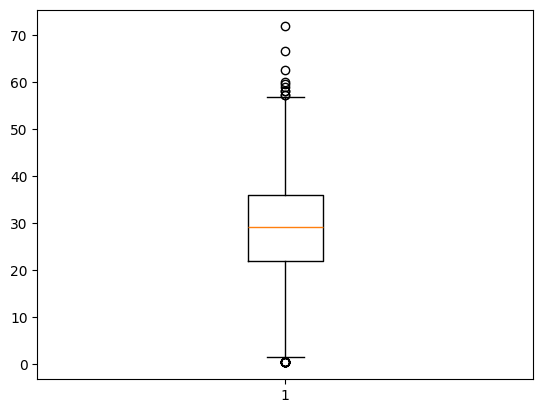

In [183]:
import matplotlib.pyplot as plt
plt.boxplot(df['Age'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7b765ad894f0>,
 'caps': [<matplotlib.lines.Line2D at 0x7b765ad89af0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b765ad891f0>],
 'medians': [<matplotlib.lines.Line2D at 0x7b765ad8a000>],
 'fliers': [<matplotlib.lines.Line2D at 0x7b765ad8a2d0>],
 'means': []}

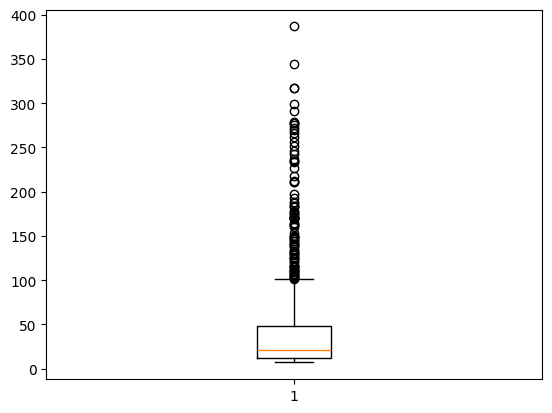

In [184]:
plt.boxplot(df['Fare'])

In [185]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
df = df[(df['Age'] >= lower)&(df['Age'] <= upper)]

In [186]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
df = df[(df['Fare'] >= lower)&(df['Fare'] <= upper)]

In [187]:
df.drop('Name',axis=1)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,2,female,31.7,1,0,395625,28.5164,NaN,S
1,2,1,3,female,26.9,0,0,PC 68031,10.5514,NaN,Q
2,3,0,3,male,16.7,0,0,969559,12.2902,NaN,S
3,4,0,3,female,9.2,0,0,692520,9.4552,NaN,S
5,6,0,1,male,30.7,1,0,916392,41.8993,C80,S
...,...,...,...,...,...,...,...,...,...,...,...
885,886,1,1,female,24.8,4,0,421220,36.9672,C86,S
886,887,0,3,male,7.7,0,0,PC 85351,14.4932,NaN,S
887,888,0,1,male,25.7,0,2,PC 43541,73.8157,C23,S
889,890,0,2,male,38.1,1,0,593570,11.8691,NaN,S


In [200]:
df.drop(['Name'], axis=1, inplace=True)

In [201]:
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,1,2,female,31.7,1,0,28.5164,S
1,2,1,3,female,26.9,0,0,10.5514,Q
2,3,0,3,male,16.7,0,0,12.2902,S
3,4,0,3,female,9.2,0,0,9.4552,S
5,6,0,1,male,30.7,1,0,41.8993,S
...,...,...,...,...,...,...,...,...,...
885,886,1,1,female,24.8,4,0,36.9672,S
886,887,0,3,male,7.7,0,0,14.4932,S
887,888,0,1,male,25.7,0,2,73.8157,S
889,890,0,2,male,38.1,1,0,11.8691,S


In [204]:
X = df.drop(columns=['Survived'])
Y = df['Survived']

In [206]:
cols = ['Sex','Embarked']
X = pd.get_dummies(X,columns=cols,dtype=int)

In [207]:
X

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,2,31.7,1,0,28.5164,1,0,0,0,1
1,2,3,26.9,0,0,10.5514,1,0,0,1,0
2,3,3,16.7,0,0,12.2902,0,1,0,0,1
3,4,3,9.2,0,0,9.4552,1,0,0,0,1
5,6,1,30.7,1,0,41.8993,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
885,886,1,24.8,4,0,36.9672,1,0,0,0,1
886,887,3,7.7,0,0,14.4932,0,1,0,0,1
887,888,1,25.7,0,2,73.8157,0,1,0,0,1
889,890,2,38.1,1,0,11.8691,0,1,0,0,1


In [208]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [209]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cols_to_scale = ['Pclass','Age','Fare']
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
print(X_train[cols_to_scale].head())

       Pclass       Age      Fare
154  0.749079 -0.432559 -0.786604
862  0.749079  1.128749 -0.613532
66  -1.889721  0.081754  1.926125
467  0.749079  1.872666 -0.407611
773 -0.570321  0.320542 -0.791562


In [210]:
df['Survived'].value_counts()

,count
Survived,
0,467
1,308


In [211]:
df['Survived'].value_counts(normalize=True) * 100

,proportion
Survived,
0,60.258065
1,39.741935


In [212]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, Y)

In [223]:
y_resampled.value_counts(normalize=True)*100

,proportion
Survived,
1,50.0
0,50.0


In [222]:
df['Survived'].value_counts(normalize=True) * 100

,proportion
Survived,
0,60.258065
1,39.741935


In [214]:
print(f"X_train shape: {X_train.shape}, Y_train shape: {Y_train.shape}")
print(f"X_test shape:  {X_test.shape},  Y_test shape:  {Y_test.shape}")

X_train shape: (620, 11), Y_train shape: (620,)
X_test shape:  (155, 11),  Y_test shape:  (155,)


In [215]:
print(X_train.columns.tolist())

['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


In [216]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression(max_iter=100)
LR.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [217]:
y_predict = LR.predict(X_test)
y_predict

array([1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0])

In [221]:
from sklearn.metrics import accuracy_score, recall_score,precision_score,f1_score,confusion_matrix

print("--- Logistic Regression Model Metrics ---")
print(f"Accuracy:  {accuracy_score(Y_test, y_predict):.4f}")
print(f"Recall:    {recall_score(Y_test, y_predict):.4f}")
print(f"Precision: {precision_score(Y_test, y_predict):.4f}")
print(f"F1 Score:  {f1_score(Y_test, y_predict):.4f}")
print("Confusion Matrix :",confusion_matrix(Y_test,y_predict))

--- Logistic Regression Model Metrics ---
Accuracy:  0.8065
Recall:    0.7018
Precision: 0.7547
F1 Score:  0.7273
Confusion Matrix : [[85 13]
 [17 40]]
